# Figure 2D

In [ ]:
### Load protein similarity values for UHVDB
# import polars as pl
# import glob
# import random

# final_reps_set = set(pl.read_csv('vclust/uhvdb_vclust_votu_reps_final.tsv', separator='\t', has_header=False)['column_1'])

# all_norm_scores = (
#     pl.read_csv('protein_similarity/all_norm_scores.tsv', separator='\t', new_columns=['query', 'reference', 'norm_score'], has_header=False)
#         .filter(
#             (pl.col('norm_score') >= 0) &
#             (pl.col('query').is_in(final_reps_set)) &
#             (pl.col('reference').is_in(final_reps_set))
#         )
# )

In [ ]:
### Iteratively sample database chunks and get best hits to next chunk
# combined_best_hits = pl.DataFrame()

# final_reps_shuffle = list(final_reps_set)
# random.shuffle(final_reps_shuffle)

# for i in range(1, 20):
#     print(f"Processing chunk {i}")
#     # extract chunks of 10,000 ids 
#     current_db_ids = set(final_reps_shuffle[0:i*10000])
#     next_chunk_ids = set(final_reps_shuffle[i*10000:(i+1)*10000])
#     curr_best_hits = (
#         all_norm_scores
#             .filter(pl.col('reference').is_in(current_db_ids) & pl.col('query').is_in(next_chunk_ids))
#             .sort('norm_score', descending=True)
#             .group_by('query', maintain_order=True)
#             .first()
#             .with_columns([
#                 pl.lit(i*10000).alias('chunk')
#             ])[['query', 'chunk', 'norm_score']]
#     )
#     combined_best_hits = pl.concat([combined_best_hits, curr_best_hits])

# combined_best_hits.write_csv('similarity_rarefaction.tsv', separator='\t', include_header=True)


(0.0, 200000.0)

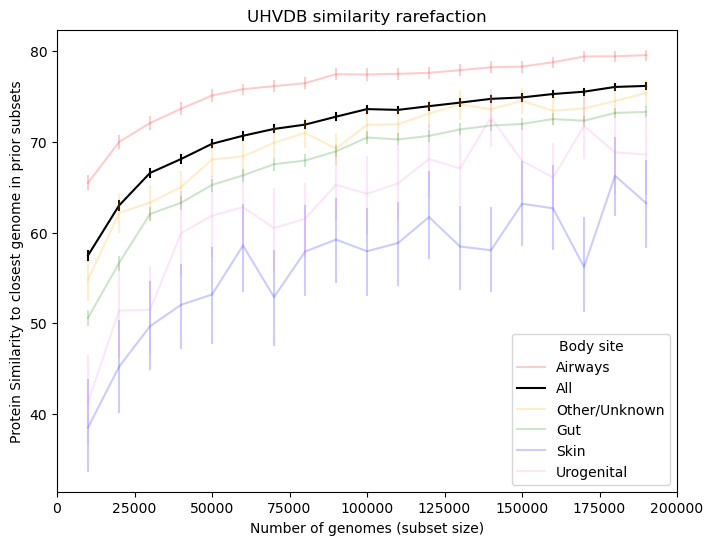

In [2]:
### Plot accumulation curve
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# load uhvdb metadata
uhvdb_metadata = pl.read_csv('../figure_1/uhvdb_final_metadata.tsv', separator='\t')

plot_df = (
    pl.concat([
        pl.read_csv('similarity_rarefaction.tsv', separator='\t').join(uhvdb_metadata[['seq_name', 'body_site']], left_on='query', right_on='seq_name', how='left'),
        pl.read_csv('similarity_rarefaction.tsv', separator='\t').with_columns([pl.lit('All').alias('body_site')])  # add a row for all body sites
    ])
    .with_columns([
        pl.col('body_site').str.replace('Oral', 'Airways')
    ])
)

# # add 0 values for chunk 0
# all_body_sites = plot_df['body_site'].unique()
# zero_chunk = pl.DataFrame()
# for site in all_body_sites:
#     zero_chunk = pl.concat([zero_chunk, pl.DataFrame({
#         'query': [f'placeholder_{site}'],
#         'chunk': [0],
#         'norm_score': [0.0],
#         'body_site': [site]
#     })])
# plot_df = pl.concat([plot_df, zero_chunk])
# 'Other/Unknown', 'Gut', 'Urogenital', 'Skin'
# '#A3F781', '#81F5F7', '#8A81F7', '#E581F7'
plt.figure(figsize=(8, 6))
sns.lineplot(x="chunk", y="norm_score", hue='body_site', palette=['red'], data=plot_df.filter(pl.col('body_site') == 'Airways'), alpha=0.2, err_style='bars')
sns.lineplot(x="chunk", y="norm_score", hue='body_site', palette=['black'], data=plot_df.filter(pl.col('body_site') == 'All'), alpha=1.0, err_style='bars')
sns.lineplot(x="chunk", y="norm_score", hue='body_site', palette=['orange'], data=plot_df.filter(pl.col('body_site') == 'Other/Unknown'), alpha=0.2, err_style='bars')
sns.lineplot(x="chunk", y="norm_score", hue='body_site', palette=['green'], data=plot_df.filter(pl.col('body_site') == 'Gut'), alpha=0.2, err_style='bars')
sns.lineplot(x="chunk", y="norm_score", hue='body_site', palette=['blue'], data=plot_df.filter(pl.col('body_site') == 'Skin'), alpha=0.2, err_style='bars')
sns.lineplot(x="chunk", y="norm_score", hue='body_site', palette=['violet'], data=plot_df.filter(pl.col('body_site') == 'Urogenital'), alpha=0.2, err_style='bars')
plt.title("UHVDB similarity rarefaction")
plt.xlabel("Number of genomes (subset size)")
plt.ylabel("Protein Similarity to closest genome in prior subsets")
plt.legend(title='Body site', loc='lower right')
plt.xlim(0,200000)
# plt.yscale('log')